🎲 GENERATING COMPLETELY RANDOM GRIDS
📋 RANDOM GRID CONFIGURATION:
   num_grids: 1000000
   grid_size: (7, 7)
   land_use_types: 5
   save_grids: True
   analyze_grids: True
   visualize_samples: True

💡 You can modify RANDOM_CONFIG['num_grids'] to generate a different number of grids
   Current setting: 1,000,000 grids

🚀 Starting random grid generation...
🎯 Generating 1,000,000 completely random 7×7 grids...
   Each grid has 49 cells with 5 possible land use types
✅ Generated 1,000,000 completely random grids

📊 RANDOM GRID ANALYSIS:
   Total grids: 1,000,000
   Total cells: 49,000,000
   Residential: 9,794,994 cells (20.0%)
✅ Generated 1,000,000 completely random grids

📊 RANDOM GRID ANALYSIS:
   Total grids: 1,000,000
   Total cells: 49,000,000
   Residential: 9,794,994 cells (20.0%)
   Industrial: 9,801,483 cells (20.0%)
   Commercial: 9,796,154 cells (20.0%)
   Parks: 9,803,025 cells (20.0%)
   Industrial: 9,801,483 cells (20.0%)
   Commercial: 9,796,154 cells (20.0%)
   Parks: 9,

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7444\2704529954.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


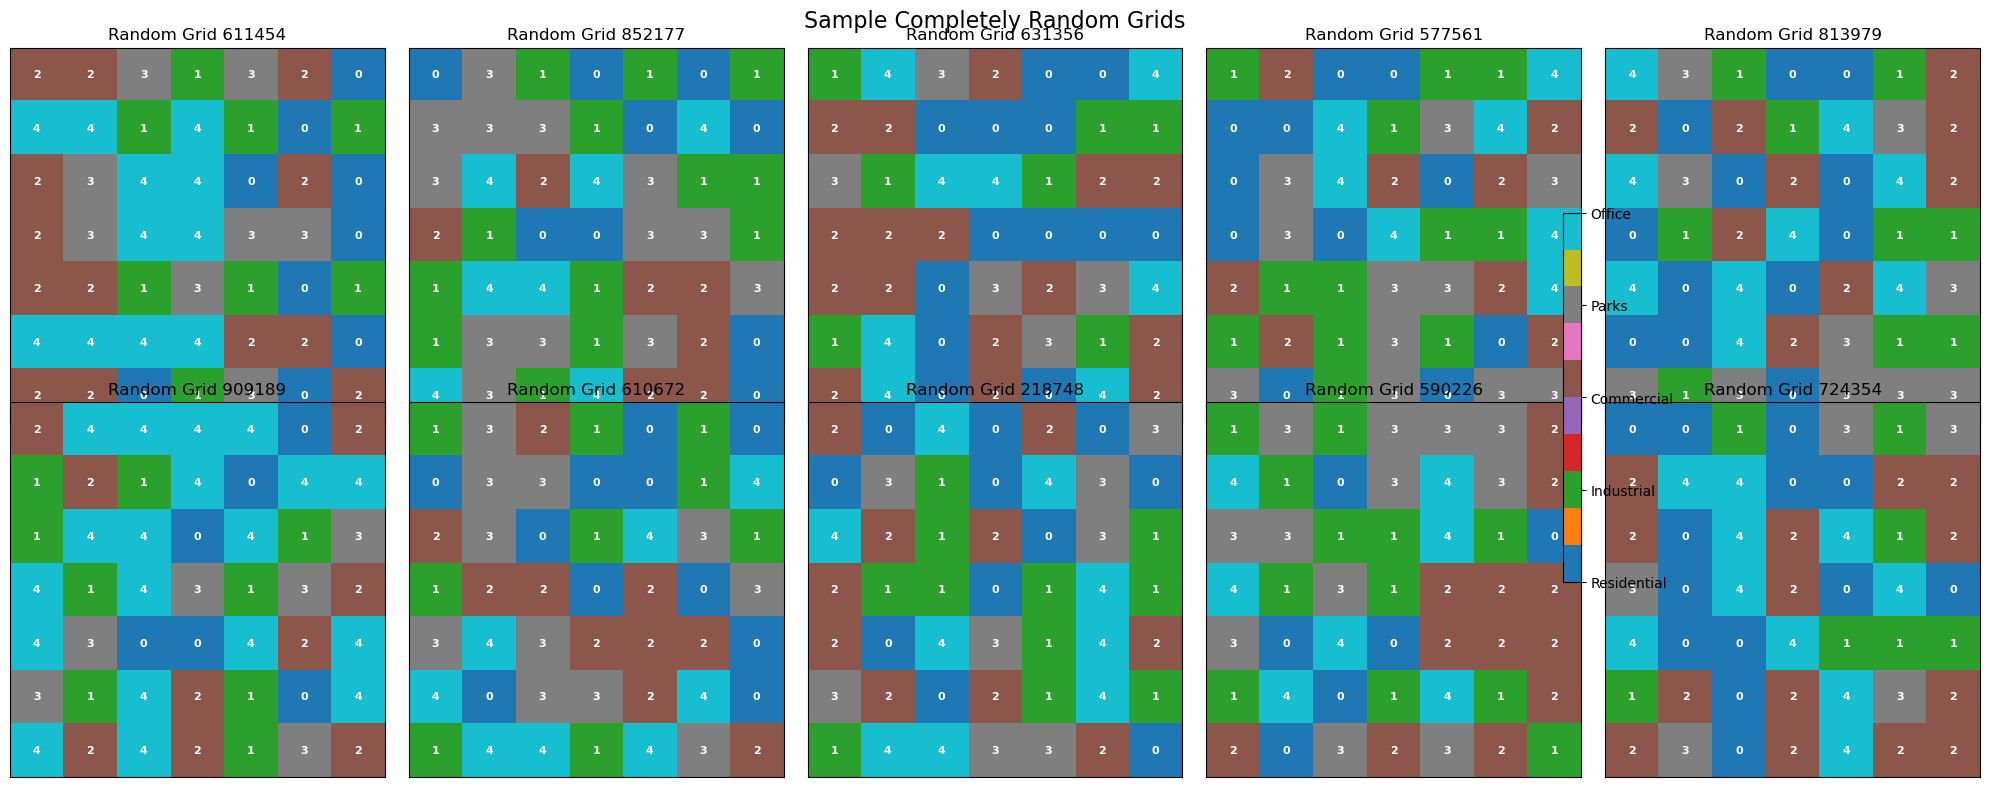


💾 Saving random grids...
   ✅ Saved 1,000,000 random grids: data/generated_grids/random_grids_20251104_000732.npy
   ✅ Saved random grid statistics: data/generated_grids/random_grid_stats_20251104_000732.npy
   ✅ Saved metadata: data/generated_grids/random_metadata_20251104_000732.npy

🎉 Random grid generation complete!
🎲 Generated 1,000,000 completely random grids with uniform land use distribution
💡 These can serve as baseline comparison for constraint-based generation methods
📁 Files saved with timestamp: 20251104_000732
   ✅ Saved 1,000,000 random grids: data/generated_grids/random_grids_20251104_000732.npy
   ✅ Saved random grid statistics: data/generated_grids/random_grid_stats_20251104_000732.npy
   ✅ Saved metadata: data/generated_grids/random_metadata_20251104_000732.npy

🎉 Random grid generation complete!
🎲 Generated 1,000,000 completely random grids with uniform land use distribution
💡 These can serve as baseline comparison for constraint-based generation methods
📁 Files sa

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 🎲 Generate Completely Random Grids
print("🎲 GENERATING COMPLETELY RANDOM GRIDS")
print("=" * 50)

def generate_random_grids(num_grids, grid_size=(7, 7), land_use_types=5):
    """
    Generate completely random grids with uniform distribution of land use types
    
    Args:
        num_grids (int): Number of random grids to generate
        grid_size (tuple): Size of each grid (rows, cols)
        land_use_types (int): Number of land use types (0-4: Residential, Industrial, Commercial, Parks, Office)
    
    Returns:
        numpy.ndarray: Array of random grids with shape (num_grids, rows, cols)
    """
    rows, cols = grid_size
    total_cells = rows * cols
    
    print(f"🎯 Generating {num_grids:,} completely random {rows}×{cols} grids...")
    print(f"   Each grid has {total_cells} cells with {land_use_types} possible land use types")
    
    # Generate random grids with uniform distribution
    random_grids = np.random.randint(0, land_use_types, size=(num_grids, rows, cols), dtype=np.int32)
    
    return random_grids

def analyze_random_grids(random_grids):
    """Analyze the properties of randomly generated grids"""
    
    num_grids = len(random_grids)
    total_cells = random_grids.size
    
    print(f"\n📊 RANDOM GRID ANALYSIS:")
    print(f"   Total grids: {num_grids:,}")
    print(f"   Total cells: {total_cells:,}")
    
    # Land use distribution
    land_use_names = ['Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
    land_use_counts = []
    
    for i in range(5):
        count = np.sum(random_grids == i)
        percentage = count / total_cells * 100
        land_use_counts.append(count)
        print(f"   {land_use_names[i]}: {count:,} cells ({percentage:.1f}%)")
    
    # Uniqueness check
    flat_grids = random_grids.reshape(num_grids, -1)
    unique_grids = np.unique(flat_grids, axis=0)
    uniqueness_rate = len(unique_grids) / num_grids
    
    print(f"\n🔍 UNIQUENESS ANALYSIS:")
    print(f"   Unique grids: {len(unique_grids):,}/{num_grids:,}")
    print(f"   Uniqueness rate: {uniqueness_rate:.1%}")
    
    # Diversity metrics (sample for efficiency if large dataset)
    if num_grids > 1000:
        sample_size = 1000
        sample_indices = np.random.choice(num_grids, sample_size, replace=False)
        sample_grids = flat_grids[sample_indices]
        print(f"   Diversity calculated on {sample_size:,} sample grids")
    else:
        sample_grids = flat_grids
        sample_size = num_grids
    
    # Calculate pairwise Hamming distances for diversity
    hamming_distances = []
    for i in range(min(100, len(sample_grids))):  # Limit for performance
        for j in range(i+1, min(100, len(sample_grids))):
            hamming_dist = np.sum(sample_grids[i] != sample_grids[j])
            hamming_distances.append(hamming_dist)
    
    if hamming_distances:
        mean_hamming = np.mean(hamming_distances)
        std_hamming = np.std(hamming_distances)
        print(f"   Mean Hamming distance: {mean_hamming:.1f} ± {std_hamming:.1f}")
        print(f"   Expected for random: ~24.5 (half of 49 cells)")
    
    return {
        'num_grids': num_grids,
        'unique_count': len(unique_grids),
        'uniqueness_rate': uniqueness_rate,
        'land_use_distribution': land_use_counts,
        'hamming_mean': np.mean(hamming_distances) if hamming_distances else 0,
        'hamming_std': np.std(hamming_distances) if hamming_distances else 0
    }

# Configuration for random grid generation
RANDOM_CONFIG = {
    'num_grids': 1000000,  # Default number of random grids
    'grid_size': (7, 7),
    'land_use_types': 5,
    'save_grids': True,
    'analyze_grids': True,
    'visualize_samples': True
}

print(f"📋 RANDOM GRID CONFIGURATION:")
for key, value in RANDOM_CONFIG.items():
    print(f"   {key}: {value}")

# Allow user to customize the number of grids
print(f"\n💡 You can modify RANDOM_CONFIG['num_grids'] to generate a different number of grids")
print(f"   Current setting: {RANDOM_CONFIG['num_grids']:,} grids")

# Generate random grids
print(f"\n🚀 Starting random grid generation...")
random_grids = generate_random_grids(
    num_grids=RANDOM_CONFIG['num_grids'],
    grid_size=RANDOM_CONFIG['grid_size'],
    land_use_types=RANDOM_CONFIG['land_use_types']
)

print(f"✅ Generated {len(random_grids):,} completely random grids")

# Analyze the generated random grids
if RANDOM_CONFIG['analyze_grids']:
    random_stats = analyze_random_grids(random_grids)
else:
    random_stats = None

# Visualize sample random grids
if RANDOM_CONFIG['visualize_samples']:
    print(f"\n🎨 Visualizing sample random grids...")
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    # Show 10 random samples
    sample_indices = np.random.choice(len(random_grids), 10, replace=False)
    
    for i, sample_idx in enumerate(sample_indices):
        ax = axes[i]
        grid = random_grids[sample_idx]
        
        im = ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
        ax.set_title(f'Random Grid {sample_idx+1}')
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add grid values as text (for small grids)
        for row in range(7):
            for col in range(7):
                ax.text(col, row, str(grid[row, col]), 
                       ha='center', va='center', fontsize=8, 
                       color='white', weight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
    cbar.set_ticks([0, 1, 2, 3, 4])
    cbar.set_ticklabels(['Residential', 'Industrial', 'Commercial', 'Parks', 'Office'])
    
    plt.suptitle('Sample Completely Random Grids', fontsize=16)
    plt.tight_layout()
    plt.show()

# Save random grids if requested
if RANDOM_CONFIG['save_grids']:
    print(f"\n💾 Saving random grids...")
    
    # Create timestamp for unique filenames
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    
    # Save random grids
    random_grids_filename = f'data/generated_grids/random_grids_{timestamp}.npy'
    np.save(random_grids_filename, random_grids)
    print(f"   ✅ Saved {len(random_grids):,} random grids: {random_grids_filename}")
    
    # Save random grid statistics
    if random_stats:
        stats_filename = f'data/generated_grids/random_grid_stats_{timestamp}.npy'
        np.save(stats_filename, random_stats)
        print(f"   ✅ Saved random grid statistics: {stats_filename}")
    
    # Save metadata
    random_metadata = {
        'timestamp': timestamp,
        'num_grids': len(random_grids),
        'grid_size': RANDOM_CONFIG['grid_size'],
        'land_use_types': RANDOM_CONFIG['land_use_types'],
        'generation_method': 'uniform_random',
        'uniqueness_rate': random_stats['uniqueness_rate'] if random_stats else None,
        'mean_hamming_distance': random_stats['hamming_mean'] if random_stats else None
    }
    
    metadata_filename = f'data/generated_grids/random_metadata_{timestamp}.npy'
    np.save(metadata_filename, random_metadata)
    print(f"   ✅ Saved metadata: {metadata_filename}")


print(f"\n🎉 Random grid generation complete!")
print(f"🎲 Generated {len(random_grids):,} completely random grids with uniform land use distribution")
print(f"💡 These can serve as baseline comparison for constraint-based generation methods")
print(f"📁 Files saved with timestamp: {timestamp if RANDOM_CONFIG['save_grids'] else 'Not saved'}")

🔄 Loading pre-trained Oracle models...
📁 Loading Wellness Oracle from data/models\wellness_oracle_model.pkl...
🔥 PyTorch available, using device: cpu
📁 Loaded PyTorch model from data/models\wellness_oracle_model_pytorch.pth
✅ Wellness Oracle loaded successfully!
📁 Loading Tax Oracle from data/models\tax_oracle_model.pkl...
🔥 PyTorch available, using device: cpu
📁 Loaded PyTorch model from data/models\tax_oracle_model_pytorch.pth
✅ Tax Oracle loaded successfully!
📁 Loading Transportation Oracle from data/models\transportation_oracle_model.pkl...
🔥 PyTorch available, using device: cpu
📁 Loaded PyTorch model from data/models\transportation_oracle_model_pytorch.pth
✅ Transportation Oracle loaded successfully!
📁 Loading Business Oracle from data/models\business_oracle_model.pkl...
🔥 PyTorch available, using device: cpu
📁 Loaded PyTorch model from data/models\business_oracle_model_pytorch.pth
✅ Business Oracle loaded successfully!

📊 Successfully loaded 4 pre-trained models:
   ✓ Wellness Or

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7444\1429977385.py:395: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


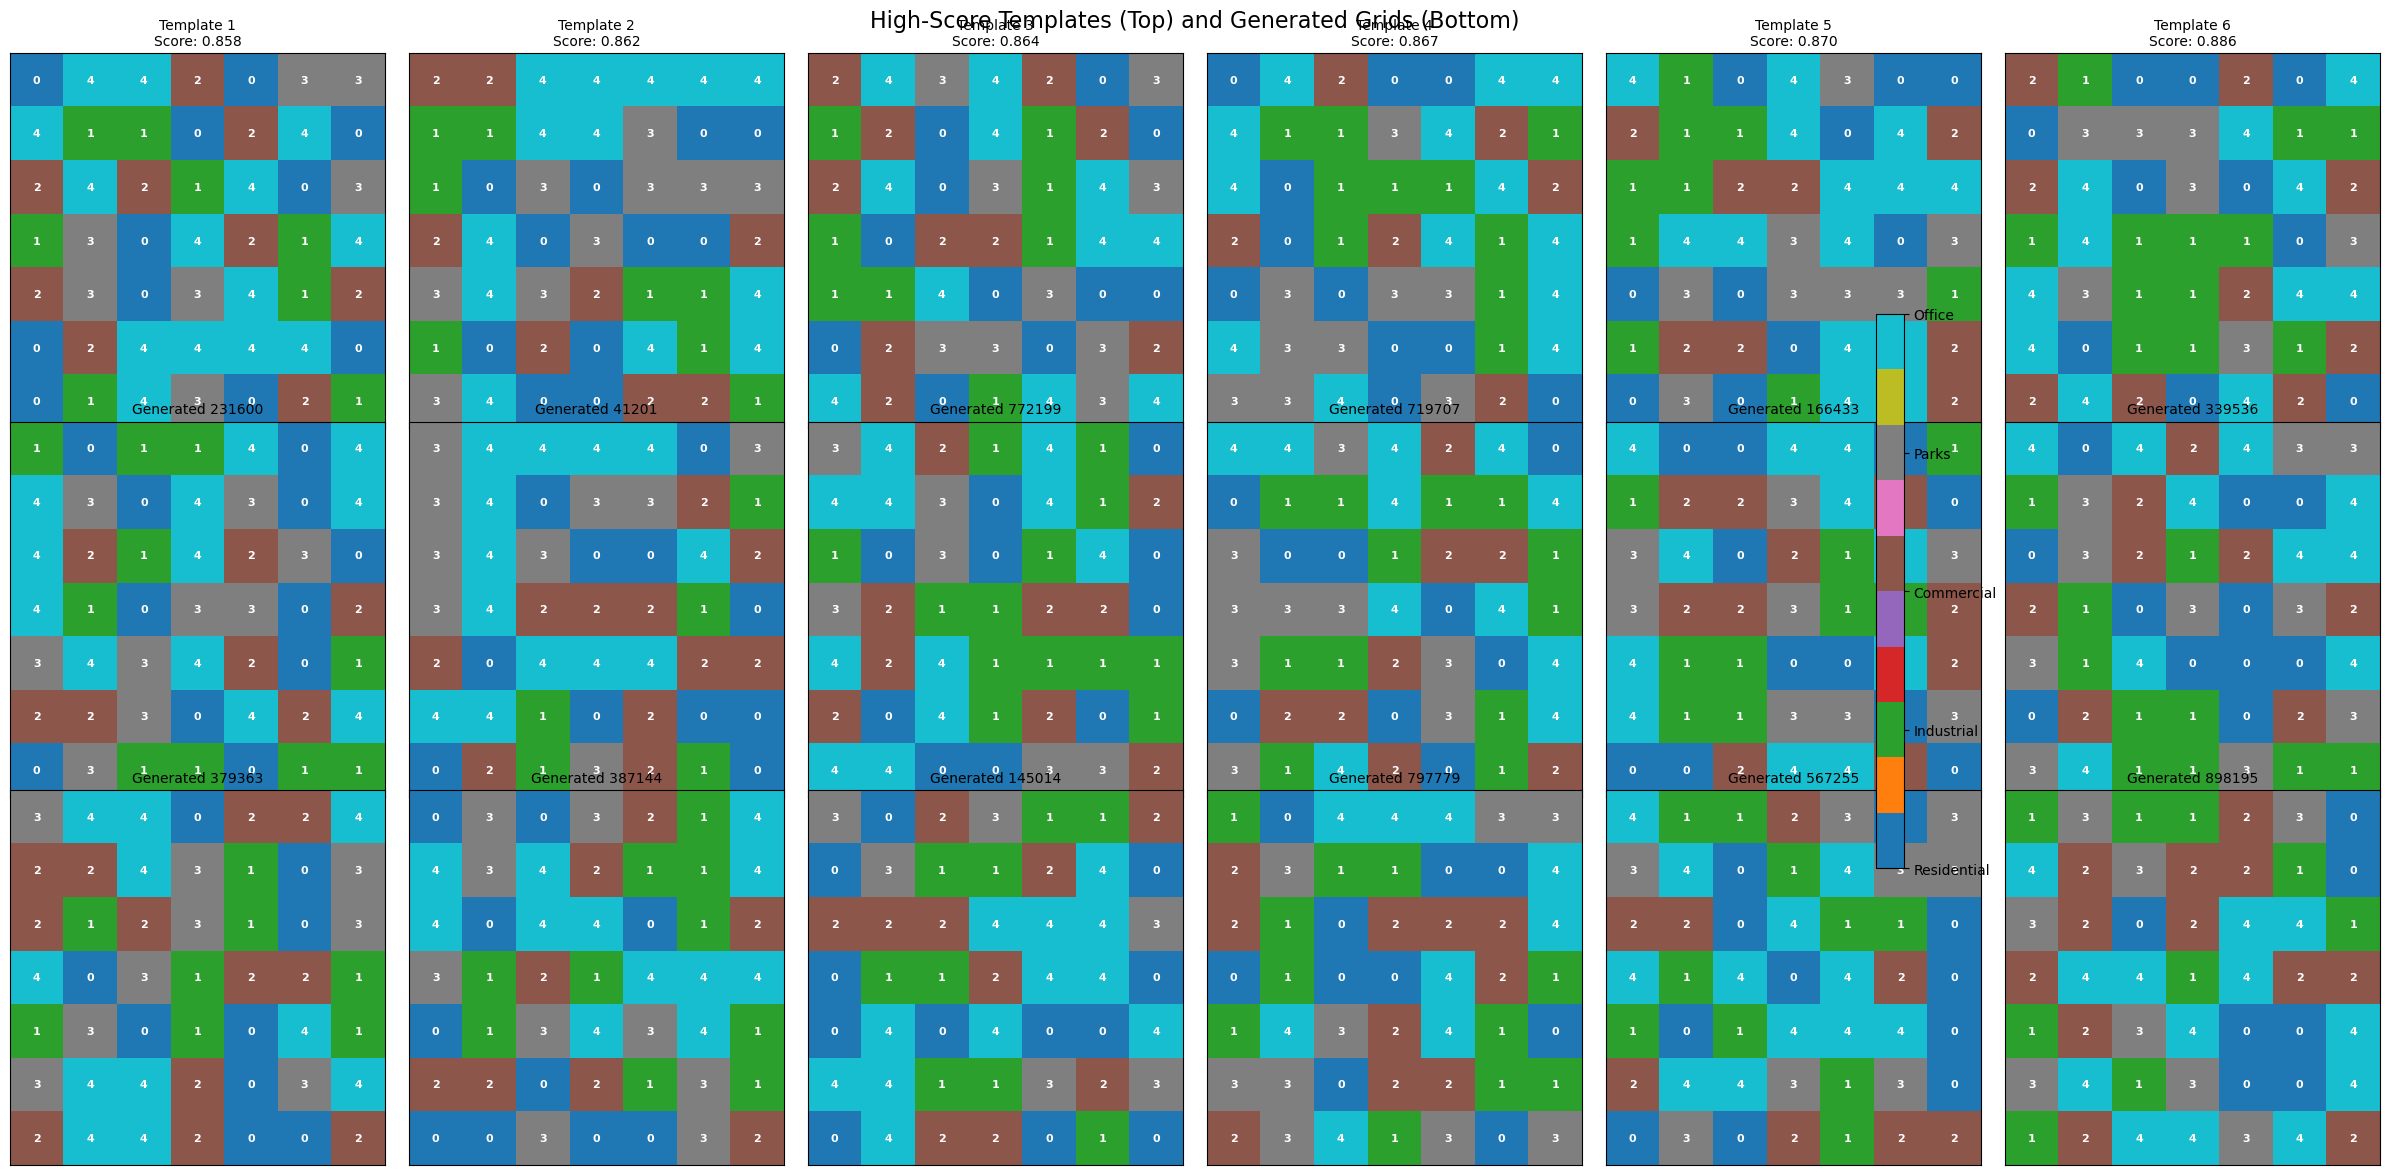


🎉 TEMPLATE-BASED GENERATION COMPLETE!
📊 Summary:
   • Evaluated 1,000,000 random grids
   • Found 2,262 high-scoring templates
   • Generated 1,000,000 new grids based on templates
   • Template score range: 0.750 - 0.886
   • Files saved with timestamp: 20251104_004421
💡 These template-based grids should have higher Oracle scores than pure random!


In [10]:
import sys
import pandas as pd
sys.path.append('.')
from utils.oracle_predictor import create_oracle_predictor

# Load Oracle predictor using the simplified approach
oracle_predictor = create_oracle_predictor()

# 🎯 Evaluate Random Grids and Generate Million Based on High Scorers
print("🎯 EVALUATING RANDOM GRIDS WITH ORACLE")
print("=" * 60)

def evaluate_grids_with_oracle(grids, batch_size=1000):
    """Evaluate grids using the Oracle predictor in batches"""
    
    num_grids = len(grids)
    all_scores = []
    
    print(f"📊 Evaluating {num_grids:,} grids in batches of {batch_size:,}...")
    
    for i in range(0, num_grids, batch_size):
        batch_end = min(i + batch_size, num_grids)
        batch_grids = grids[i:batch_end]
        
        # Get Oracle predictions for this batch (all advisors average)
        batch_predictions = oracle_predictor.predict_all_advisors(batch_grids)
        batch_scores = np.mean(batch_predictions, axis=1)
        all_scores.append(batch_scores)
        
        if (i // batch_size + 1) % 5 == 0:  # Progress update every 5 batches
            print(f"   Processed {batch_end:,}/{num_grids:,} grids...")
    
    # Combine all scores
    combined_scores = np.concatenate(all_scores)
    return combined_scores

def analyze_score_distribution(scores, threshold=0.75):
    """Analyze the distribution of Oracle scores"""
    
    print(f"\n📈 ORACLE SCORE ANALYSIS:")
    print(f"   Total grids evaluated: {len(scores):,}")
    print(f"   Mean score: {np.mean(scores):.4f}")
    print(f"   Median score: {np.median(scores):.4f}")
    print(f"   Std deviation: {np.std(scores):.4f}")
    print(f"   Min score: {np.min(scores):.4f}")
    print(f"   Max score: {np.max(scores):.4f}")
    
    # Score distribution by thresholds
    thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    print(f"\n🎯 SCORE DISTRIBUTION:")
    for thresh in thresholds:
        count = np.sum(scores >= thresh)
        percentage = count / len(scores) * 100
        print(f"   ≥ {thresh:.2f}: {count:,} grids ({percentage:.2f}%)")
    
    # High scorer analysis
    high_scorers = scores >= threshold
    high_scorer_count = np.sum(high_scorers)
    high_scorer_pct = high_scorer_count / len(scores) * 100
    
    print(f"\n🌟 HIGH SCORER ANALYSIS (≥{threshold}):")
    print(f"   High scoring grids: {high_scorer_count:,}/{len(scores):,}")
    print(f"   High scorer rate: {high_scorer_pct:.2f}%")
    
    if high_scorer_count > 0:
        high_scores = scores[high_scorers]
        print(f"   Mean high score: {np.mean(high_scores):.4f}")
        print(f"   Best high score: {np.max(high_scores):.4f}")
    
    return high_scorers, high_scorer_count

def generate_grids_from_templates(template_grids, target_count=1000000, variation_methods=None):
    """Generate new grids based on high-scoring templates"""
    
    if variation_methods is None:
        variation_methods = {
            'swap_adjacent': 0.3,      # 30% - Swap adjacent cells
            'local_mutation': 0.25,    # 25% - Mutate small local regions  
            'rotation': 0.15,          # 15% - Rotate portions of grid
            'reflection': 0.15,        # 15% - Reflect portions of grid
            'crossover': 0.15          # 15% - Combine two templates
        }
    
    print(f"\n🧬 GENERATING {target_count:,} NEW GRIDS FROM TEMPLATES")
    print(f"   Template count: {len(template_grids):,}")
    print(f"   Variation methods: {list(variation_methods.keys())}")
    
    new_grids = []
    methods_used = {method: 0 for method in variation_methods.keys()}
    
    # Calculate how many grids to generate per method
    method_counts = {}
    for method, ratio in variation_methods.items():
        method_counts[method] = int(target_count * ratio)
    
    # Generate grids using each method
    for method, count in method_counts.items():
        print(f"   Generating {count:,} grids using {method}...")
        
        method_grids = []
        for _ in range(count):
            # Select random template(s)
            template_idx = np.random.randint(0, len(template_grids))
            template = template_grids[template_idx].copy()
            
            if method == 'swap_adjacent':
                new_grid = swap_adjacent_cells(template)
            elif method == 'local_mutation':
                new_grid = mutate_local_region(template)
            elif method == 'rotation':
                new_grid = rotate_region(template)
            elif method == 'reflection':
                new_grid = reflect_region(template)
            elif method == 'crossover':
                if len(template_grids) > 1:
                    other_idx = np.random.randint(0, len(template_grids))
                    while other_idx == template_idx:
                        other_idx = np.random.randint(0, len(template_grids))
                    other_template = template_grids[other_idx]
                    new_grid = crossover_grids(template, other_template)
                else:
                    new_grid = mutate_local_region(template)  # Fallback
            
            method_grids.append(new_grid)
            methods_used[method] += 1
        
        new_grids.extend(method_grids)
    
    new_grids = np.array(new_grids, dtype=np.int32)
    
    print(f"\n✅ Generated {len(new_grids):,} new grids")
    print(f"   Methods used breakdown:")
    for method, count in methods_used.items():
        print(f"     {method}: {count:,} grids")
    
    return new_grids

def swap_adjacent_cells(grid):
    """Swap random adjacent cells in the grid"""
    new_grid = grid.copy()
    rows, cols = grid.shape
    
    # Number of swaps (1-3 random swaps)
    num_swaps = np.random.randint(1, 4)
    
    for _ in range(num_swaps):
        # Pick random cell
        r, c = np.random.randint(0, rows), np.random.randint(0, cols)
        
        # Pick random adjacent cell
        directions = [(0,1), (0,-1), (1,0), (-1,0)]
        dr, dc = directions[np.random.randint(0, 4)]
        nr, nc = r + dr, c + dc
        
        # Check bounds and swap
        if 0 <= nr < rows and 0 <= nc < cols:
            new_grid[r, c], new_grid[nr, nc] = new_grid[nr, nc], new_grid[r, c]
    
    return new_grid

def mutate_local_region(grid):
    """Mutate a small local region (2x2 or 3x3) in the grid"""
    new_grid = grid.copy()
    rows, cols = grid.shape
    
    # Choose region size (2x2 or 3x3)
    region_size = np.random.choice([2, 3])
    
    # Choose random top-left corner
    max_r = rows - region_size
    max_c = cols - region_size
    
    if max_r >= 0 and max_c >= 0:
        r = np.random.randint(0, max_r + 1)
        c = np.random.randint(0, max_c + 1)
        
        # Mutate 1-2 cells in the region
        num_mutations = np.random.randint(1, min(3, region_size * region_size))
        
        for _ in range(num_mutations):
            local_r = np.random.randint(0, region_size)
            local_c = np.random.randint(0, region_size)
            new_grid[r + local_r, c + local_c] = np.random.randint(0, 5)
    
    return new_grid

def rotate_region(grid):
    """Rotate a small region within the grid"""
    new_grid = grid.copy()
    rows, cols = grid.shape
    
    # Choose region size (2x2 or 3x3)
    region_size = np.random.choice([2, 3])
    
    # Choose random top-left corner
    max_r = rows - region_size
    max_c = cols - region_size
    
    if max_r >= 0 and max_c >= 0:
        r = np.random.randint(0, max_r + 1)
        c = np.random.randint(0, max_c + 1)
        
        # Extract region and rotate it
        region = grid[r:r+region_size, c:c+region_size].copy()
        rotated = np.rot90(region, k=np.random.randint(1, 4))
        new_grid[r:r+region_size, c:c+region_size] = rotated
    
    return new_grid

def reflect_region(grid):
    """Reflect a region horizontally or vertically"""
    new_grid = grid.copy()
    rows, cols = grid.shape
    
    # Choose region size (2x2 or 3x3)
    region_size = np.random.choice([2, 3])
    
    # Choose random top-left corner  
    max_r = rows - region_size
    max_c = cols - region_size
    
    if max_r >= 0 and max_c >= 0:
        r = np.random.randint(0, max_r + 1)
        c = np.random.randint(0, max_c + 1)
        
        # Extract region and reflect it
        region = grid[r:r+region_size, c:c+region_size].copy()
        
        # Choose reflection axis
        if np.random.random() < 0.5:
            reflected = np.fliplr(region)  # Horizontal flip
        else:
            reflected = np.flipud(region)  # Vertical flip
            
        new_grid[r:r+region_size, c:c+region_size] = reflected
    
    return new_grid

def crossover_grids(grid1, grid2):
    """Create a new grid by combining regions from two parent grids"""
    new_grid = grid1.copy()
    rows, cols = grid1.shape
    
    # Choose crossover method
    method = np.random.choice(['horizontal_split', 'vertical_split', 'checkerboard', 'random_mask'])
    
    if method == 'horizontal_split':
        split_point = np.random.randint(1, rows)
        new_grid[split_point:] = grid2[split_point:]
    
    elif method == 'vertical_split':
        split_point = np.random.randint(1, cols)
        new_grid[:, split_point:] = grid2[:, split_point:]
    
    elif method == 'checkerboard':
        mask = np.zeros((rows, cols), dtype=bool)
        mask[::2, ::2] = True
        mask[1::2, 1::2] = True
        new_grid[mask] = grid2[mask]
    
    elif method == 'random_mask':
        # Random 30-70% from second parent
        mask_ratio = 0.3 + np.random.random() * 0.4
        mask = np.random.random((rows, cols)) < mask_ratio
        new_grid[mask] = grid2[mask]
    
    return new_grid

# Step 1: Evaluate random grids with Oracle
print("🚀 Starting evaluation of random grids...")
random_scores = evaluate_grids_with_oracle(random_grids, batch_size=10000)

# Step 2: Analyze score distribution and identify high scorers
high_scorer_mask, high_scorer_count = analyze_score_distribution(random_scores, threshold=0.75)

# Check if we have any high scorers
if high_scorer_count == 0:
    print("\n⚠️  No grids found with score ≥ 0.75!")
    print("   Lowering threshold to 0.7 to find templates...")
    high_scorer_mask, high_scorer_count = analyze_score_distribution(random_scores, threshold=0.7)
    
    if high_scorer_count == 0:
        print("   Still no high scorers! Using top 1% as templates...")
        top_1_percent = max(1, int(0.01 * len(random_scores)))
        top_indices = np.argsort(random_scores)[-top_1_percent:]
        high_scorer_mask = np.zeros(len(random_scores), dtype=bool)
        high_scorer_mask[top_indices] = True
        high_scorer_count = len(top_indices)
        print(f"   Using top {high_scorer_count} grids as templates")

# Step 3: Extract high-scoring grids as templates
template_grids = random_grids[high_scorer_mask]
template_scores = random_scores[high_scorer_mask]

print(f"\n🎨 TEMPLATE EXTRACTION:")
print(f"   High-scoring templates: {len(template_grids):,}")
print(f"   Template score range: {np.min(template_scores):.4f} - {np.max(template_scores):.4f}")
print(f"   Mean template score: {np.mean(template_scores):.4f}")

# Step 4: Generate 1 million new grids based on templates
TARGET_GRIDS = 1000000
print(f"\n🎯 Generating {TARGET_GRIDS:,} grids based on high-scoring templates...")

generated_grids = generate_grids_from_templates(template_grids, target_count=TARGET_GRIDS)

# Step 5: Save the generated grids
print(f"\n💾 Saving {len(generated_grids):,} template-based grids...")

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

# Save generated grids
template_grids_filename = f'data/generated_grids/template_based_grids_{timestamp}.npy'
np.save(template_grids_filename, generated_grids)
print(f"   ✅ Saved template-based grids: {template_grids_filename}")

# Save templates and their scores
templates_filename = f'data/generated_grids/high_score_templates_{timestamp}.npy'
template_scores_filename = f'data/generated_grids/template_scores_{timestamp}.npy'
np.save(templates_filename, template_grids)
np.save(template_scores_filename, template_scores)
print(f"   ✅ Saved {len(template_grids):,} templates: {templates_filename}")
print(f"   ✅ Saved template scores: {template_scores_filename}")

# Save generation metadata
template_metadata = {
    'timestamp': timestamp,
    'original_random_grids': len(random_grids),
    'templates_count': len(template_grids),
    'generated_count': len(generated_grids),
    'score_threshold': 0.75,
    'actual_min_template_score': float(np.min(template_scores)),
    'mean_template_score': float(np.mean(template_scores)),
    'max_template_score': float(np.max(template_scores)),
    'generation_methods': ['swap_adjacent', 'local_mutation', 'rotation', 'reflection', 'crossover'],
    'target_grids': TARGET_GRIDS
}

template_metadata_filename = f'data/generated_grids/template_metadata_{timestamp}.npy'
np.save(template_metadata_filename, template_metadata)
print(f"   ✅ Saved generation metadata: {template_metadata_filename}")

# Step 6: Quick visualization of some templates and generated grids
print(f"\n🎨 Visualizing templates and generated examples...")

fig, axes = plt.subplots(3, 6, figsize=(24, 12))

# Top row: Show best templates
if len(template_grids) >= 6:
    best_template_indices = np.argsort(template_scores)[-6:]
    for i, idx in enumerate(best_template_indices):
        ax = axes[0, i]
        grid = template_grids[idx]
        score = template_scores[idx]
        
        im = ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
        ax.set_title(f'Template {i+1}\nScore: {score:.3f}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add grid values
        for row in range(7):
            for col in range(7):
                ax.text(col, row, str(grid[row, col]), 
                       ha='center', va='center', fontsize=8, 
                       color='white', weight='bold')

# Middle & bottom rows: Show generated examples
sample_indices = np.random.choice(len(generated_grids), 12, replace=False)

for i, sample_idx in enumerate(sample_indices):
    row = 1 + i // 6
    col = i % 6
    ax = axes[row, col]
    grid = generated_grids[sample_idx]
    
    im = ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
    ax.set_title(f'Generated {sample_idx+1}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add grid values
    for r in range(7):
        for c in range(7):
            ax.text(c, r, str(grid[r, c]), 
                   ha='center', va='center', fontsize=8, 
                   color='white', weight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(['Residential', 'Industrial', 'Commercial', 'Parks', 'Office'])

plt.suptitle('High-Score Templates (Top) and Generated Grids (Bottom)', fontsize=16)
plt.tight_layout()
plt.show()

print(f"\n🎉 TEMPLATE-BASED GENERATION COMPLETE!")
print(f"📊 Summary:")
print(f"   • Evaluated {len(random_grids):,} random grids")
print(f"   • Found {len(template_grids):,} high-scoring templates")
print(f"   • Generated {len(generated_grids):,} new grids based on templates")
print(f"   • Template score range: {np.min(template_scores):.3f} - {np.max(template_scores):.3f}")
print(f"   • Files saved with timestamp: {timestamp}")
print(f"💡 These template-based grids should have higher Oracle scores than pure random!")